# 01 — Baselines: la media y la regresión lineal

**Componente B — predicción de rinde.** El problema es de *regresión supervisada*:
estimar el rinde (`rinde_kgha`, kg/ha) de un departamento-campaña a partir de las
variables climáticas de la campaña.

Antes de tunear modelos hay que fijar el **piso**: ¿qué tan lejos llega lo trivial?
Este notebook establece tres referencias en orden creciente de sofisticación:

1. **Media global** — predecir siempre el rinde medio de train. El baseline más
   tonto posible; su R² es 0 por construcción sobre train.
2. **Media por departamento** (climatología) — predecir, para cada fila, el rinde
   histórico medio de su departamento. Captura la estructura *espacial* (un depto
   rinde sistemáticamente más que otro) y es el baseline agronómico honesto.
3. **Regresión lineal (OLS)** — el primer modelo que usa el clima.

Los datos, el split temporal (train ≤2020, test ≥2021) y las features están en
`datos.py`; las métricas y baselines en `evaluacion.py`.

In [14]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))          # componente_b/ (datos, evaluacion)
warnings.filterwarnings('ignore')                  # silenciar ConvergenceWarning de sklearn

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

import datos, evaluacion as ev
from modelos import (LinearRegressor, XGBoostRegressor, NeuralNetRegressor,
                     RandomForestRegressorModel, HistGBMRegressor, StackingRegressorModel)

# Todo el análisis se hace sobre los DOS cultivos. El dataset "principal" usa las
# features agronómicas de ventana crítica (use_agro) y el suavizado del target
# encoding de depto (enc_smooth): la configuración que mejor generaliza.
CULTIVOS = ['soja', 'maiz']
DSS = {c: datos.prepare(c, use_agro=True, enc_smooth=10.0) for c in CULTIVOS}
for c in CULTIVOS:
    d = DSS[c]
    print(f'{c:5s}: {len(d.feature_cols)} features | '
          f'train {d.X_train.shape[0]} filas (≤{datos.TRAIN_END}) | '
          f'test {d.X_test.shape[0]} filas (≥{datos.TEST_START})')


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
soja : 78 features | train 7551 filas (≤2020) | test 942 filas (≥2021)
maiz : 78 features | train 9678 filas (≤2020) | test 1160 filas (≥2021)


## Los datos

Las features que ve el modelo son de tres tipos (todas escaladas con parámetros de
train, sin leakage): **clima mensual** (Sep–Mar), **codificación del departamento**
por su rinde medio en train (estructura espacial) y el **año** (tendencia
tecnológica). El target es el rinde crudo en kg/ha.

In [15]:
for c in CULTIVOS:
    d = DSS[c]
    print(f'--- {c} ---  features: {d.feature_cols[:4]} ... {d.feature_cols[-2:]}')
    print(f'  rinde train: media={d.y_train.mean():.0f}  std={d.y_train.std():.0f} kg/ha | '
          f'test: media={d.y_test.mean():.0f}  std={d.y_test.std():.0f} kg/ha')

--- soja ---  features: ['allsky_sfc_sw_dwn_sep', 'allsky_sfc_sw_dwn_oct', 'allsky_sfc_sw_dwn_nov', 'allsky_sfc_sw_dwn_dic'] ... ['depto_enc', 'year']
  rinde train: media=2235  std=795 kg/ha | test: media=2355  std=766 kg/ha
--- maiz ---  features: ['allsky_sfc_sw_dwn_sep', 'allsky_sfc_sw_dwn_oct', 'allsky_sfc_sw_dwn_nov', 'allsky_sfc_sw_dwn_dic'] ... ['depto_enc', 'year']
  rinde train: media=4678  std=2356 kg/ha | test: media=5495  std=2007 kg/ha


## Baselines (ambos cultivos)

Para regresión reportamos cuatro métricas (definidas en `evaluacion.metricas`):
**MAE** y **RMSE** en kg/ha (RMSE castiga más los errores grandes), **R²** (varianza
explicada; 0 = tan bueno como predecir la media, negativo = peor) y **sMAPE**. Todo
el análisis se hace para soja **y** maíz.

In [16]:
def baselines_ols(c):
    d = DSS[c]
    ols = LinearRegressor(penalty='none').fit(d.X_train, d.y_train)
    return [{'cultivo': c, **ev.evaluar('media global',  ev.pred_media(d),       d)},
            {'cultivo': c, **ev.evaluar('media x depto',  ev.pred_media_depto(d), d)},
            {'cultivo': c, **ev.evaluar('OLS (lineal)',   ols.predict(d.X_test),  d)}]

filas = [f for c in CULTIVOS for f in baselines_ols(c)]
tabla = pd.DataFrame(filas)[['cultivo', 'modelo', 'mae', 'rmse', 'r2', 'smape']]
tabla

,cultivo,modelo,mae,rmse,r2,smape
0,soja,media global,651.750,775.593,-0.025,29.488
1,soja,media x depto,593.307,708.357,0.145,27.169
2,soja,OLS (lineal),507.877,665.019,0.247,23.644
3,maiz,media global,"1,761.949","2,166.230",-0.166,35.140
4,maiz,media x depto,"1,500.686","1,785.230",0.208,31.662
5,maiz,OLS (lineal),"1,515.887","1,972.562",0.034,29.313


La **media por departamento** ya explica bastante más varianza que la media global:
casi todo el poder predictivo "fácil" del rinde es *dónde* está el campo, no el
clima del año. Ese es el número que cualquier modelo con clima tiene que superar.
La OLS con clima mejora sobre ese piso en ambos cultivos.

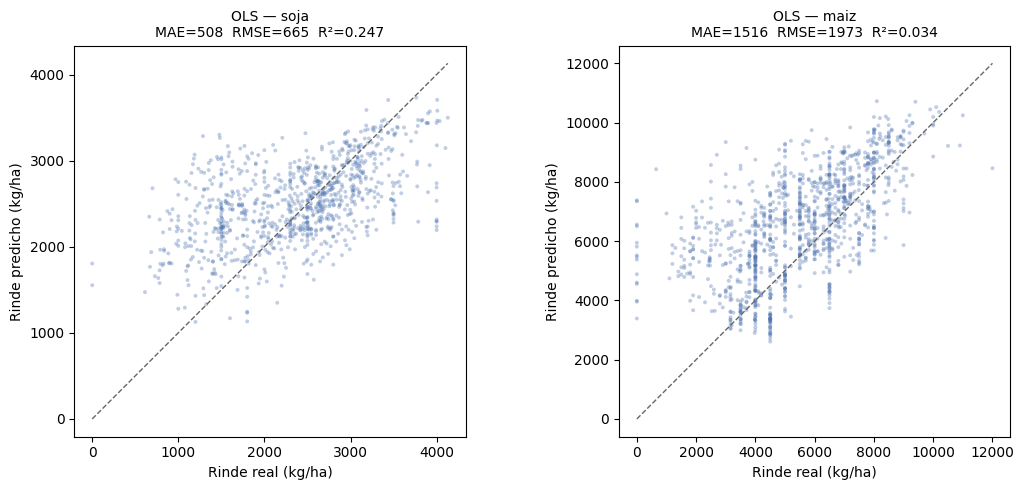

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, c in zip(axes, CULTIVOS):
    d = DSS[c]
    ols = LinearRegressor(penalty='none').fit(d.X_train, d.y_train)
    ev.plot_pred_vs_real(d.y_test, ols.predict(d.X_test), f'OLS — {c}',
                         color=ev.C_LINEAR, ax=ax)
plt.tight_layout(); plt.show()

## Conclusión

- La **media por departamento** es un baseline fuerte: el grueso de la señal del
  rinde es espacial.
- La **OLS** aprovecha el clima y la tendencia y mejora sobre la media por depto,
  pero sin regularizar es propensa a la colinealidad (las 54 columnas mensuales
  están muy correlacionadas entre sí).

Los notebooks siguientes tunean cada familia de modelos: regularización para el
lineal (02), XGBoost (03) y red neuronal (04); la comparación final es el 05.